In [1]:
## This is code for WASNet: Wavelet-Attentive SEBAM Network for Robust SAR Image Change Detection paper
## Please cite paper when you use it. Thank you
# Dr Mohamed Ihmeida at BCU


In [2]:
# !pip install timm

In [3]:
# !pip install torch torchvision torchaudio

In [4]:
# !pip install pytorch-msssim

In [5]:
!pip install PyWavelets

In [6]:
import numpy as np
# from preclassify import dicomp, hcluster
import cv2
import torch
import torch.nn as nn
import time
from sklearn.manifold import TSNE
from scipy import io as sio
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch.optim as optim
from einops.layers.torch import Rearrange
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader
from timm.models.layers import trunc_normal_
from torch.autograd import Function
# from torch_wavelets import DWT_2D, IDWT_2D
import pywt
from skimage import io, measure
import random
import math
from tqdm.notebook import tqdm
import os
from PIL import Image
from scipy import signal
from scipy.linalg import norm
from scipy.spatial.distance import cdist
from scipy.ndimage import uniform_filter
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Function
from torch.autograd import Variable, gradcheck
import torch.optim as optim
from tqdm import tqdm
from torch.optim.lr_scheduler import StepLR
from skimage.filters import threshold_otsu
from scipy import signal
from scipy.linalg import norm
from scipy.spatial.distance import cdist
from torch.autograd import Function


/usr/local/lib/python3.11/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [7]:
def pair(t):
    return t if isinstance(t, tuple) else (t, t)

seed = 3407

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(seed)

In [8]:

def del2(im):
    [ylen, xlen] = im.shape
    im_new = np.zeros([ylen, xlen], dtype=np.float32)
    for j in range(1, ylen - 1):
        for i in range(1, xlen - 1):
            im_new[j, i] = (im[j - 1, i] + im[j + 1, i] + im[j, i - 1] + im[j, i + 1]) / 4 - im[j, i]
    return im_new


def srad(im, delta):
    q0 = 1
    for n in range(1, 6):
        [ylen, xlen] = im.shape
        X = np.zeros([ylen + 2, xlen + 2], dtype=np.float32)
        X[1:ylen + 1, 1:xlen + 1] = im
        # padding
        X[0, 1:xlen + 1] = im[0, :]
        X[ylen + 1, 1:xlen + 1] = im[ylen - 1, :]
        X[:, 0] = X[:, 1]
        X[:, xlen + 1] = X[:, xlen]

        q0 = q0 * np.exp(-delta)
        gRx = signal.convolve2d(X, [[0, 0, 0], [0, 1, -1], [0, 0, 0]], mode='same', boundary='symm')
        gRy = signal.convolve2d(X, [[0, -1, 0], [0, 1, 0], [0, 0, 0]], mode='same', boundary='symm')
        gLx = signal.convolve2d(X, [[0, 0, 0], [1, -1, 0], [0, 0, 0]], mode='same', boundary='symm')
        gLy = signal.convolve2d(X, [[0, 0, 0], [0, -1, 0], [0, 1, 0]], mode='same', boundary='symm')
        q1 = np.sqrt(gRx * gRx + gRy * gRy + gLx * gLx + gLy * gLy) / (X + 0.0001)
        q2 = 4 * del2(X) / (X + 0.0001)

       # Safeguard against negative values inside sqrt
        numerator = 0.5 * q1**2 - 0.0625 * q2**2
        denominator = (1 + 0.25 * q2)**2 + 0.01
        argument = numerator / denominator
        argument = np.maximum(argument, 0)  # Ensure non-negative
        q = np.sqrt(argument)

        # q = np.sqrt((1 / 2 * (q1 * q1) - 1 / 16 * (q2 * q2)) / ((1 + 1 / 4 * q2) * (1 + 1 / 4 * q2) + 0.01))
        c = 1 / (1 + ((q * q - q0 * q0) / (q0 * q0 * (1 + q0 * q0))))
        d = signal.convolve2d(c, [[0, 0, 0], [0, 0, -1], [0, 0, 0]], mode='same', boundary='symm') * \
            signal.convolve2d(X, [[0, 0, 0], [0, 1, -1], [0, 0, 0]], mode='same', boundary='symm') + \
            signal.convolve2d(c, [[0, 0, 0], [0, -1, 0], [0, 0, 0]], mode='same', boundary='symm') * \
            signal.convolve2d(X, [[0, 0, 0], [-1, 1, 0], [0, 0, 0]], mode='same', boundary='symm') + \
            signal.convolve2d(c, [[0, -1, 0], [0, 0, 0], [0, 0, 0]], mode='same', boundary='symm') * \
            signal.convolve2d(X, [[0, -1, 0], [0, 1, 0], [0, 0, 0]], mode='same', boundary='symm') + \
            signal.convolve2d(c, [[0, 0, 0], [0, -1, 0], [0, 0, 0]], mode='same', boundary='symm') * \
            signal.convolve2d(X, [[0, 0, 0], [0, 1, 0], [0, -1, 0]], mode='same', boundary='symm')
        X = X + delta / 4 * d
        im = X[1:ylen + 1, 1:xlen + 1]
    return im


def dicomp(im1, im2):
    im1 = srad(im1, 0.15)
    im2 = srad(im2, 0.15)
    im_di = abs(np.log((im1 + 1) / (im2 + 1)))
    im_di = srad(im_di, 0.15)
    return im_di
    # im1-im2


In [9]:
# hiearchical FCM clustering
# in the preclassification map,
# pixels with high probability to be unchanged are labeled 1
# pixels with high probability to be changed are labeled 2
# pixels with uncertainty are labeled 1.5

def hcluster(pix_vec, im_di):
    print('... ... 1st round clustering ... ...')
    fcm = FCM(n_clusters=2)
    fcm.fit(pix_vec)
    fcm_lab = fcm.u.argmax(axis=1)

## Upper and lower bounds on the number of pixels in the change category
    if sum(fcm_lab == 0) < sum(fcm_lab == 1):
        ttr = round(sum(fcm_lab == 0) * 1.25)
        ttl = round(sum(fcm_lab == 0) / 1.10)
    else:
        ttr = round(sum(fcm_lab == 1) * 1.25)
        ttl = round(sum(fcm_lab == 1) / 1.10)

    print('... ... 2nd round clustering ... ...')
    fcm = FCM(n_clusters=5)
    fcm.fit(pix_vec)
    fcm_lab = fcm.u.argmax(axis=1)
    ylen, xlen = im_di.shape
    idx = []
    idx_tmp = []
    idxmean = []
    res_lab = np.zeros(ylen * xlen, dtype=np.float32)
    for i in range(0, 5):
        idx_tmp.append(np.argwhere(fcm_lab == i))
        idxmean.append(im_di.reshape(ylen * xlen, 1)[idx_tmp[i]].mean())

    idx_sort = np.argsort(idxmean)
    for i in range(0, 5):
        idx.append(idx_tmp[idx_sort[i]])
    c = len(idx[4])
    res_lab[idx[4]] = 2
    flag_mid = 0
    for i in range(1, 5):
        c = c + len(idx[4 - i])
        if c < ttl:
            res_lab[idx[4 - i]] = 2
        elif c >= ttl and c < ttr:
            res_lab[idx[4 - i]] = 1.5
            flag_mid = 1
        elif flag_mid == 0:
            res_lab[idx[4 - i]] = 1.5
            flag_mid = 1
        else:
            res_lab[idx[4 - i]] = 1
    res_lab = res_lab.reshape(ylen, xlen)
    return res_lab


class FCM:
    def __init__(self, n_clusters=10, max_iter=150, m=2, error=1e-5, random_state=42):
        self.u, self.centers = None, None
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.m = m
        self.error = error
        self.random_state = random_state

    def fit(self, X):
        N = X.shape[0]
        C = self.n_clusters
        centers = []
        r = np.random.RandomState(self.random_state)
        u = r.rand(N, C)
        u = u / np.tile(u.sum(axis=1)[np.newaxis].T, C)
        iteration = 0
        while iteration < self.max_iter:
            u2 = u.copy()
            centers = self.next_centers(X, u)
            u = self.next_u(X, centers)
            iteration += 1
            # Stopping rule
            if norm(u - u2) < self.error:
                break
        self.u = u
        self.centers = centers
        return self

    def next_centers(self, X, u):
        um = u ** self.m
        return (X.T @ um / np.sum(um, axis=0)).T

    def next_u(self, X, centers):
        return self._predict(X, centers)

    def _predict(self, X, centers):
        power = float(2 / (self.m - 1))
        temp = cdist(X, centers) ** power
        denominator_ = temp.reshape((X.shape[0], 1, -1)).repeat(temp.shape[-1], axis=1)
        denominator_ = temp[:, :, np.newaxis] / denominator_
        return 1 / denominator_.sum(2)

    def predict(self, X):
        if len(X.shape) == 1:
            X = np.expand_dims(X, axis=0)
        u = self._predict(X, self.centers)
        return np.argmax(u, axis=-1)

In [10]:
## Proposed WASNet

# =============================================================================
# Custom autograd function for Discrete Wavelet Transform (DWT)
# =============================================================================
class DWT_Function(Function):
    @staticmethod
    def forward(ctx, x, w_ll, w_lh, w_hl, w_hh):
        # Ensure x is contiguous
        x = x.contiguous()
        # Save filters for backward pass
        ctx.save_for_backward(w_ll, w_lh, w_hl, w_hh)
        ctx.shape = x.shape

        dim = x.shape[1]
        # Perform grouped convolution for each filter
        x_ll = torch.nn.functional.conv2d(x, w_ll.expand(dim, -1, -1, -1), stride=2, groups=dim)
        x_lh = torch.nn.functional.conv2d(x, w_lh.expand(dim, -1, -1, -1), stride=2, groups=dim)
        x_hl = torch.nn.functional.conv2d(x, w_hl.expand(dim, -1, -1, -1), stride=2, groups=dim)
        x_hh = torch.nn.functional.conv2d(x, w_hh.expand(dim, -1, -1, -1), stride=2, groups=dim)
        # Concatenate outputs along the channel dimension
        x = torch.cat([x_ll, x_lh, x_hl, x_hh], dim=1)
        return x

    @staticmethod
    def backward(ctx, dx):
        if ctx.needs_input_grad[0]:
            w_ll, w_lh, w_hl, w_hh = ctx.saved_tensors
            B, C, H, W = ctx.shape
            # Reshape gradients to match the four components
            dx = dx.view(B, 4, -1, H // 2, W // 2)
            dx = dx.transpose(1, 2).reshape(B, -1, H // 2, W // 2)
            # Concatenate filters and repeat them for grouped transpose convolution
            filters = torch.cat([w_ll, w_lh, w_hl, w_hh], dim=0).repeat(C, 1, 1, 1)
            dx = torch.nn.functional.conv_transpose2d(dx, filters, stride=2, groups=C)

        return dx, None, None, None, None


# =============================================================================
# Custom autograd function for Inverse Discrete Wavelet Transform (IDWT)
# =============================================================================
class IDWT_Function(Function):
    @staticmethod
    def forward(ctx, x, filters):
        ctx.save_for_backward(filters)
        ctx.shape = x.shape

        B, _, H, W = x.shape
        x = x.view(B, 4, -1, H, W).transpose(1, 2)
        C = x.shape[1]
        x = x.reshape(B, -1, H, W)

        # Convert filters to the same data type as the input x
        # filters = filters.to(x.dtype) # Remove this line
        filters = filters.type(x.dtype) # Cast filter to the type of x


        filters = filters.repeat(C, 1, 1, 1)
        x = torch.nn.functional.conv_transpose2d(x, filters, stride=2, groups=C)
        return x

    @staticmethod
    def backward(ctx, dx):
        if ctx.needs_input_grad[0]:
            filters = ctx.saved_tensors[0]
            B, C, H, W = ctx.shape
            C = C // 4
            dx = dx.contiguous()

            # Unbind the filters and perform convolutions (assuming filters remain in a compatible dtype)
            w_ll, w_lh, w_hl, w_hh = torch.unbind(filters, dim=0)
            # Ensure dx and filters have the same dtype
            w_ll = w_ll.type(dx.dtype)
            w_lh = w_lh.type(dx.dtype)
            w_hl = w_hl.type(dx.dtype)
            w_hh = w_hh.type(dx.dtype)

            x_ll = torch.nn.functional.conv2d(dx, w_ll.unsqueeze(1).expand(C, -1, -1, -1), stride=2, groups=C)
            x_lh = torch.nn.functional.conv2d(dx, w_lh.unsqueeze(1).expand(C, -1, -1, -1), stride=2, groups=C)
            x_hl = torch.nn.functional.conv2d(dx, w_hl.unsqueeze(1).expand(C, -1, -1, -1), stride=2, groups=C)
            x_hh = torch.nn.functional.conv2d(dx, w_hh.unsqueeze(1).expand(C, -1, -1, -1), stride=2, groups=C)
            dx = torch.cat([x_ll, x_lh, x_hl, x_hh], dim=1)
        return dx, None


# =============================================================================
# IDWT_2D Module with Learnable Inverse Wavelet Filters (using float32)
# =============================================================================
class IDWT_2D(nn.Module):
    def __init__(self, wave):
        super(IDWT_2D, self).__init__()
        w = pywt.Wavelet(wave)
        rec_hi = torch.Tensor(w.rec_hi)
        rec_lo = torch.Tensor(w.rec_lo)

        # Compute reconstruction filters using wavelet coefficients
        w_ll = rec_lo.unsqueeze(0) * rec_lo.unsqueeze(1)
        w_lh = rec_lo.unsqueeze(0) * rec_hi.unsqueeze(1)
        w_hl = rec_hi.unsqueeze(0) * rec_lo.unsqueeze(1)
        w_hh = rec_hi.unsqueeze(0) * rec_hi.unsqueeze(1)

        # Add necessary dimensions for convolution (format: [out_channels, in_channels, H, W])
        w_ll = w_ll.unsqueeze(0).unsqueeze(1)
        w_lh = w_lh.unsqueeze(0).unsqueeze(1)
        w_hl = w_hl.unsqueeze(0).unsqueeze(1)
        w_hh = w_hh.unsqueeze(0).unsqueeze(1)
        # Concatenate the four filters along the first dimension
        filters = torch.cat([w_ll, w_lh, w_hl, w_hh], dim=0)

        # ---------------------------------------------------------------------
        # Suggestion 1: Make the filters learnable by using nn.Parameter instead
        # of registering them as buffers.
        # ---------------------------------------------------------------------
        self.filters = nn.Parameter(filters.float())  # use float32 for higher precision

    def forward(self, x):
        # Use the custom IDWT function with learnable filters
        return IDWT_Function.apply(x, self.filters)


# =============================================================================
# DWT_2D Module with Learnable Wavelet Filters (using float32)
# =============================================================================
class DWT_2D(nn.Module):
    def __init__(self, wave):
        super(DWT_2D, self).__init__()
        w = pywt.Wavelet(wave)
        # Reverse the decomposition coefficients as per wavelet definition
        dec_hi = torch.Tensor(w.dec_hi[::-1])
        dec_lo = torch.Tensor(w.dec_lo[::-1])

        # Compute decomposition filters using wavelet coefficients
        w_ll = dec_lo.unsqueeze(0) * dec_lo.unsqueeze(1)
        w_lh = dec_lo.unsqueeze(0) * dec_hi.unsqueeze(1)
        w_hl = dec_hi.unsqueeze(0) * dec_lo.unsqueeze(1)
        w_hh = dec_hi.unsqueeze(0) * dec_hi.unsqueeze(1)

 # ---------------------------------------------------------------------
   # Suggestion: Make these filters learnable by using nn.Parameter. # Also, ensure we use float32 precision.
# ---------------------------------------------------------------------
        self.w_ll = nn.Parameter(w_ll.unsqueeze(0).unsqueeze(0).float())
        self.w_lh = nn.Parameter(w_lh.unsqueeze(0).unsqueeze(0).float())
        self.w_hl = nn.Parameter(w_hl.unsqueeze(0).unsqueeze(0).float())
        self.w_hh = nn.Parameter(w_hh.unsqueeze(0).unsqueeze(0).float())

    def forward(self, x):
        # Use the custom DWT function with the learnable filters
        return DWT_Function.apply(x, self.w_ll, self.w_lh, self.w_hl, self.w_hh)


In [11]:
def image_normalize(data):
    import math
    _mean = np.mean(data)
    _std = np.std(data)
    npixel = np.size(data) * 1.0
    min_stddev = 1.0 / math.sqrt(npixel)
    return (data - _mean) / max(_std, min_stddev)

def image_padding(data, r):
    if len(data.shape) == 3:
        # Use np.pad directly instead of np.lib.pad
        data_new = np.pad(data, ((r, r), (r, r), (0, 0)), 'constant', constant_values=0)
        return data_new
    if len(data.shape) == 2:
        # Use np.pad directly instead of np.lib.pad
        data_new = np.pad(data, r, 'constant', constant_values=0)
        return data_new

def arr(length):
    arr = np.arange(length) # Change to np.arange(length) to include all indices
    random.shuffle(arr)
    return arr

def createTrainingCubes(X, y, patch_size):
    margin = int((patch_size - 1) / 2) + 1
    zeroPaddedX = image_padding(X, margin)
    ele_num1 = np.sum(y == 1)
    ele_num2 = np.sum(y == 2)
    patchesData_1 = np.zeros((ele_num1, patch_size, patch_size, X.shape[2]))
    patchesLabels_1 = np.zeros(ele_num1)
    patchesData_2 = np.zeros((ele_num2, patch_size, patch_size, X.shape[2]))
    patchesLabels_2 = np.zeros(ele_num2)

    patchIndex_1 = 0
    patchIndex_2 = 0
    for r in range(margin, zeroPaddedX.shape[0] - margin):
        for c in range(margin, zeroPaddedX.shape[1] - margin):
            # remove uncertainty pixels
            if y[r - margin, c - margin] == 1:
                patch_1 = zeroPaddedX[r - margin:r + margin, c - margin:c + margin]
                patchesData_1[patchIndex_1, :, :, :] = patch_1
                patchesLabels_1[patchIndex_1] = y[r - margin, c - margin]
                patchIndex_1 = patchIndex_1 + 1
            elif y[r - margin, c - margin] == 2:
                patch_2 = zeroPaddedX[r - margin:r + margin, c - margin:c + margin]
                patchesData_2[patchIndex_2, :, :, :] = patch_2
                patchesLabels_2[patchIndex_2] = y[r - margin, c - margin]
                patchIndex_2 = patchIndex_2 + 1
    patchesLabels_1 = patchesLabels_1 - 1
    patchesLabels_2 = patchesLabels_2 - 1

    arr_1 = arr(len(patchesData_1))
    arr_2 = arr(len(patchesData_2))

    train_len = 10000
    num_samples_from_patchesData_2 = min(3000, len(patchesData_2)) # Change here: Limit num of samples
    pdata = np.zeros((train_len, patch_size, patch_size, X.shape[2]))
    plabels = np.zeros(train_len)
    for i in range(7000):
        pdata[i, :, :, :] = patchesData_1[arr_1[i], :, :, :]
        plabels[i] = patchesLabels_1[arr_1[i]]
    for j in range(num_samples_from_patchesData_2): # Change here: iterate for num of samples from patchesData_2
        pdata[j + 7000, :, :, :] = patchesData_2[arr_2[j], :, :, :] # Change here: Use arr_2[j]
        plabels[j + 7000] = patchesLabels_2[arr_2[j]] # Change here: Use arr_2[j]

    return pdata, plabels

def createTestingCubes(X, patch_size):
    margin = int((patch_size - 1) / 2) + 1
    zeroPaddedX = image_padding(X, margin)
    patchesData = np.zeros((X.shape[0] * X.shape[1], patch_size, patch_size, X.shape[2]))
    patchIndex = 0
    for r in range(margin, zeroPaddedX.shape[0] - margin):
        for c in range(margin, zeroPaddedX.shape[1] - margin):
            patch = zeroPaddedX[r - margin:r + margin, c - margin:c + margin]
            patchesData[patchIndex, :, :, :] = patch
            patchIndex = patchIndex + 1
    return patchesData


def evaluate(gtImg, tstImg):
    # Binarise input images
    gtImg = np.where(gtImg > 128, 1, 0)
    tstImg = np.where(tstImg > 128, 1, 0)

    # Flatten for evaluation
    gt_flat = gtImg.flatten()
    pred_flat = tstImg.flatten()

    # Compute confusion matrix elements
    TP = np.sum((gt_flat == 1) & (pred_flat == 1))  # True Positive
    FP = np.sum((gt_flat == 0) & (pred_flat == 1))  # False Positive
    FN = np.sum((gt_flat == 1) & (pred_flat == 0))  # False Negative
    TN = np.sum((gt_flat == 0) & (pred_flat == 0))  # True Negative

    # Compute metrics
    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)
    f1_score = 2 * precision * recall / (precision + recall + 1e-8)

    # Print results
    print('Change Detection Results:')
    print(f'  Precision : {precision * 100:.2f}%')
    print(f'  Recall    : {recall * 100:.2f}%')
    print(f'  F1 Score  : {f1_score * 100:.2f}%')

    return precision, recall, f1_score


def postprocess(res):
    res_new = res.copy() # Create a copy to avoid modifying the original array
    # Change: Apply np.where on the first two dimensions
    res_2d = res[:, :, 0] # Select the first channel to represent change/no-change
    res_labeled = measure.label(res_2d, connectivity=2)
    num = res_labeled.max()

    for i in range(1, num + 1):
        # Change: Use res_labeled for finding connected components
        idy, idx = np.where(res_labeled == i)
        if len(idy) <= 20:
            # Change: Update all channels of res_new
            res_new[idy, idx] = 0
    return res_new

(291, 306)
(291, 306)
(291, 306)
(291, 306)
... ... 1st round clustering ... ...
... ... 2nd round clustering ... ...
... ... hiearchical clustering finished !!!


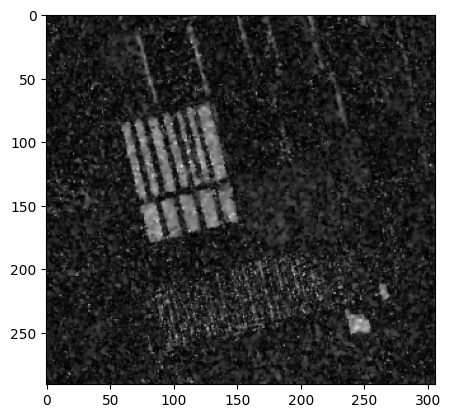

In [12]:

im1_path  = 'Farmland_1.png'  #the original images
im2_path = 'Farmland_2.png'
imgt_path = 'Farmland_gt.png'

im1 = io.imread(im1_path)[:,:,0].astype(np.float32)
# plt.imshow(im1)
print(im1.shape)


im2 = io.imread(im2_path)[:,:,0].astype(np.float32)
print(im2.shape)

im_gt = io.imread(imgt_path)[:,:].astype(np.float32)
print(im2.shape)


patch_size = 8


im_di = dicomp(im1, im2)
plt.imshow(im_di, cmap='gray')
# cv2.imwrite('di.png', im_di)
print(im_di.shape)


ylen, xlen = im_di.shape
pix_vec = im_di.reshape([ylen * xlen, 1])

preclassify_lab = hcluster(pix_vec, im_di)
print('... ... hiearchical clustering finished !!!')

mdata = np.zeros([im1.shape[0], im1.shape[1], 3], dtype=np.float32)
mdata[:, :, 0] = im1
mdata[:, :, 1] = im2


mdata[:, :, 2] = im_di
mlabel = preclassify_lab

x_train, y_train = createTrainingCubes(mdata, mlabel, patch_size)
x_train = x_train.transpose(0, 3, 1, 2)
# print(y_train.shape) #[10000]
x_test = createTestingCubes(mdata, patch_size)
x_test = x_test.transpose(0, 3, 1, 2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class TrainDS(torch.utils.data.Dataset):
    def __init__(self):
        self.len = x_train.shape[0]
        self.x_data = torch.FloatTensor(x_train)
        self.y_data = torch.LongTensor(y_train)

    def __getitem__(self, index):
        return self.x_data[index], self.y_data[index]

    def __len__(self):
        return self.len

trainset = TrainDS()

train_loader = torch.utils.data.DataLoader(dataset=trainset, batch_size=128, shuffle=True, num_workers=2)

In [13]:
class WaveAttention(nn.Module):

    def __init__(self, sr_ratio, dim, heads, dropout):
        super(WaveAttention, self).__init__()
        self.heads = heads
        self.dim = dim
        head_dim = dim // heads
        self.head_dim = dim // heads
        self.sr_ratio = sr_ratio
        self.scale = head_dim ** -0.5
        self.dwt = DWT_2D(wave="haar")
        self.idwt = IDWT_2D(wave="haar")

        self.reduce = nn.Sequential(
            nn.Conv2d(dim, dim // 4, kernel_size=1, padding=0, stride=1),
            nn.BatchNorm2d(dim // 4),
            nn.ReLU(inplace=True)
        )
        self.filter = nn.Sequential(
            nn.Conv2d(dim, dim, kernel_size=3, padding=1, stride=1, groups=1),
            nn.BatchNorm2d(dim),
            nn.ReLU(inplace=True)
        )
        self.q = nn.Linear(dim, dim)
        self.kv = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, dim * 2)
        )

        self.kv_embed = nn.Conv2d(dim, dim, kernel_size=sr_ratio, stride=sr_ratio) if sr_ratio > 1 else nn.Identity()

        self.proj = nn.Sequential(
            nn.Linear(dim + dim // 4, dim),
            nn.Dropout(dropout)
        )

        self.apply(self._init_weights)


    def forward(self, x, H, W):
        B, N, C = x.shape
        q = self.q(x).reshape(B, N, self.heads, self.head_dim).permute(0, 2, 1, 3)
        # checkShape("q", q)
        x = x.view(B, H, W, C).permute(0, 3, 1, 2)
        x = self.reduce(x)
        # x = torch.tensor(x, device=device).type(torch.float16) # float16
        x = torch.tensor(x, device=device, dtype=torch.float32)  # float32 for better f1

        x_dwt = self.dwt(x)
        x_dwt = x_dwt.float()
        x_dwt = self.filter(x_dwt)

        x_dwt = x_dwt.half()
        x_idwt = self.idwt(x_dwt)
        x_idwt = x_idwt.view(B, -1, x_idwt.size(-2) * x_idwt.size(-1)).transpose(1, 2)

        x_dwt = x_dwt.float()
        kv = self.kv_embed(x_dwt).reshape(B, C, -1).permute(0, 2, 1)
        kv = self.kv(kv).reshape(B, -1, 2, self.heads, self.head_dim).permute(2, 0, 3, 1, 4)
        k = kv[0]
        v = kv[1]
        attn = torch.matmul(q, k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        x = torch.matmul(attn, v).transpose(1, 2).reshape(B, N, C)  # N ->H*W
        x = self.proj(torch.cat([x, x_idwt], dim=-1))
        return x


    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
        elif isinstance(m, nn.Conv2d):
            fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
            fan_out //= m.groups
            m.weight.data.normal_(0, math.sqrt(2.0 / fan_out))
            if m.bias is not None:
                m.bias.data.zero_()

class WSM(nn.Module):
    def __init__(self, *, image_size, patch_size, num_classes, dim, depth, heads, mlp_dim, pool='cls', channels=3,
                 dim_head=64, dropout=0., emb_dropout=0.):
        super().__init__()
        image_height, image_width = pair(image_size)
        patch_height, patch_width = pair(patch_size)
        assert image_height % patch_height == 0 and image_width % patch_width == 0, 'Image dimensions must be ' \
                                                                                    'divisible by the patch size. '
        num_patches = (image_height // patch_height) * (image_width // patch_width)
        patch_dim = channels * patch_height * patch_width
        assert pool in {'cls', 'mean'}, 'pool type must be either cls (cls token) or mean (mean pooling)'
        self.to_patch_embedding = nn.Sequential(
            Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=patch_height, p2=patch_width),
            nn.Linear(patch_dim, dim),
        )
        self.transformer = WaveAttention(sr_ratio=2, dim=dim, heads=heads, dropout=dropout)
        self.reshape = Rearrange('b (h w) (p1 p2  c) -> b (h p1) (w p2) c', p1=patch_height, p2=patch_width,
                                 h=image_height // patch_height)

    def forward(self, img):
        x = self.to_patch_embedding(img)
        x = self.transformer(x, H=4, W=4)
        x = self.reshape(x)
        return x

wsm = WSM(image_size=8, patch_size=2, num_classes=2, dim=12, depth=6, heads=4, mlp_dim=32).to(device)

In [14]:
##  simplify  (combines the SEBlock and MHSA into the BiAttn block)
class SEBlock(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super(SEBlock, self).__init__()
        reduced_channels = in_channels // reduction
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, reduced_channels, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(reduced_channels, in_channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.global_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)


class MHSA(nn.Module):
    def __init__(self, in_channels, num_heads=2):  # Reduced number of heads for simplicity
        super(MHSA, self).__init__()
        self.num_heads = num_heads
        self.scale = (in_channels // num_heads) ** -0.5
        self.qkv = nn.Linear(in_channels, in_channels * 3, bias=False)

    def forward(self, x):
        B, C, H, W = x.shape
        x = x.flatten(2).permute(0, 2, 1)  # [B, H*W, C]

        # Apply qkv linear layer and split into query, key, and value tensors
        qkv = self.qkv(x)
        q, k, v = qkv.chunk(3, dim=-1)

        q = q.view(B, H * W, self.num_heads, C // self.num_heads).permute(0, 2, 1, 3)
        k = k.view(B, H * W, self.num_heads, C // self.num_heads).permute(0, 2, 3, 1)
        v = v.view(B, H * W, self.num_heads, C // self.num_heads).permute(0, 2, 1, 3)

        attn = (q @ k) * self.scale
        attn = attn.softmax(dim=-1)
        x = (attn @ v).permute(0, 2, 1, 3).reshape(B, H, W, C)
        return x.permute(0, 3, 1, 2)  # Back to [B, C, H, W]


class BiAttn(nn.Module):
    def __init__(self, in_channels, reduction_ratio=16, num_heads=2):  # Simplified head count
        super(BiAttn, self).__init__()
        self.se_block = SEBlock(in_channels, reduction=reduction_ratio)
        self.mhsa = MHSA(in_channels, num_heads=num_heads)

    def forward(self, x):
        ori_x = x
        x_channel = self.se_block(x)
        x_spatial = self.mhsa(x_channel)
        return ori_x * x_spatial


In [15]:
class ConcactFeature(nn.Module):
    def __init__(self, dim=3):
        super(ConcactFeature, self).__init__()
        self.catConv = nn.Conv2d(3, 3, kernel_size=1)
        self.norm1 = nn.LayerNorm([3, patch_size, patch_size])
        self.conv = nn.Conv2d(3, 3, 1)

    def forward(self, x):
        x = self.catConv(x)
        x = self.norm1(x)
        x = self.conv(x)
        return x

class WBANet(nn.Module):
    def __init__(self):
        super(WBANet, self).__init__()
        self.wsm = wsm
        self.bam = SEBlock(in_channels=8)  ##SEBlock and  ## here BiAttn  and was in_channels=3, it is 8 with MHSA
        self.cf = ConcactFeature()
        self.linear1 = nn.Linear(patch_size * patch_size * 3, 20)
        self.linear2 = nn.Linear(20, 2)
        self.drop = nn.Dropout(0.2)
        self.catConv = nn.Conv2d(6, 3, kernel_size=1)


    def forward(self, img):
        wsmOut = self.wsm(img)
        bamOut = self.bam(img.permute(0, 2, 3, 1))
        catOut = torch.cat((wsmOut, bamOut), 3).permute(0, 3, 1, 2)
        catOut = self.catConv(catOut)

        x = self.cf(catOut)

        out1 = x.view(x.size(0), -1)  # 128 192
        out = self.linear1(out1)
        out = self.linear2(out)
        return out



In [16]:
#Alpha Parameter
s= float(input("Please enter the value of S:"))
# s= 0


Please enter the value of S:6


In [17]:

# Define the MSE + CE loss function
class MSE_CE_Loss(nn.Module):
    def __init__(self, alpha= s, num_classes=2):  ##alpha = 0.5
        """
        Combines MSE and Cross-Entropy Loss.

        :param alpha: Weight for MSE loss (default 0.5), CE weight will be (1 - alpha).
        :param num_classes: Number of classes for one-hot encoding.
        """
        super(MSE_CE_Loss, self).__init__()
        self.alpha = alpha
        self.num_classes = num_classes
        self.mse_loss = nn.MSELoss()
        self.ce_loss = nn.CrossEntropyLoss()

    def forward(self, pred, target):
        """
        :param pred: Model predictions (logits for CE, continuous for MSE)
        :param target: Ground truth labels (int for CE, continuous for MSE)
        """
        # Convert target to one-hot encoding for MSE loss
        target_one_hot = torch.nn.functional.one_hot(target, num_classes=self.num_classes).float()

        # Compute losses
        mse = self.mse_loss(pred, target_one_hot)  # MSE expects float inputs
        ce = self.ce_loss(pred, target)  # CE expects class indices

        return self.alpha * mse + (1 - self.alpha) * ce


# Hyperparameters
gamma = 0.75
lr = 5e-3
epochs = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model, loss function, optimizer, and scheduler
model = WBANet().to(device)
criterion = MSE_CE_Loss(alpha= s, num_classes=2).to(device) # 0.5

optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = StepLR(optimizer, step_size=1, gamma=gamma)

# Training loop
start_time = time.time()
for epoch in range(epochs):
    epoch_loss = 0
    epoch_accuracy = 0
    model.train()  # Set model to training mode

    for data, label in tqdm(train_loader):
        data = data.to(device)
        label = label.to(device)

        # Forward pass
        output = model(data)
        loss = criterion(output, label)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calculate accuracy
        acc = (output.argmax(dim=1) == label).float().mean()
        epoch_accuracy += acc / len(train_loader)
        epoch_loss += loss / len(train_loader)

    # Print epoch results
    print(f"Epoch {epoch + 1} - Loss: {epoch_loss:.4f} - Accuracy: {epoch_accuracy:.4f}")

    # Update learning rate
    scheduler.step()

# Calculate execution time
end_time = time.time()
execution_time = end_time - start_time
print(f"Training completed in {execution_time:.4f} seconds")



/usr/local/lib/python3.11/dist-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")
  0%|          | 0/79 [00:00<?, ?it/s]<ipython-input-13-7e1608e57e52>:47: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, device=device, dtype=torch.float32)  # float32 for better f1
100%|██████████| 79/79 [00:02<00:00, 32.29it/s]


Epoch 1 - Loss: -1.7006 - Accuracy: 0.8331


100%|██████████| 79/79 [00:01<00:00, 73.02it/s]


Epoch 2 - Loss: -2.0163 - Accuracy: 0.9498


100%|██████████| 79/79 [00:01<00:00, 64.72it/s]


...

Epoch 8 - Loss: -2.0250 - Accuracy: 0.9658


100%|██████████| 79/79 [00:01<00:00, 63.01it/s]


Epoch 9 - Loss: -2.0252 - Accuracy: 0.9665


100%|██████████| 79/79 [00:00<00:00, 92.58it/s] 

Epoch 10 - Loss: -2.0254 - Accuracy: 0.9659
Training completed in 12.1710 seconds


<ipython-input-13-7e1608e57e52>:47: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, device=device, dtype=torch.float32)  # float32 for better f1


ylen: 291, xlen: 306
... ... row 50  handling ... ...
... ... row 100  handling ... ...
... ... row 150  handling ... ...
... ... row 200  handling ... ...
... ... row 250  handling ... ...


Change Detection Results:
  Precision : 93.51%
  Recall    : 86.34%
  F1 Score  : 89.78%


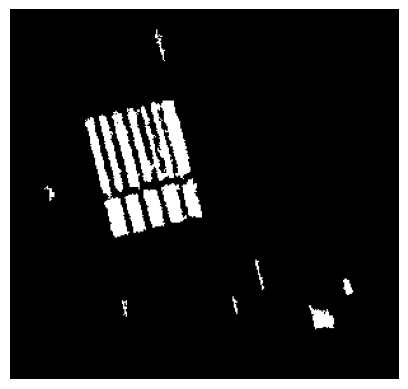

test run time: 18.4659 seconds


True

In [18]:
# @title
model.eval()
outputs = np.zeros_like(im_gt)  # Initialize with same shape as im_gt
# outputs = np.zeros((ylen, xlen))
start_time = time.time()
# Get dimensions of the images

# Change: Access only the first two dimensions of im_gt.shape
ylen, xlen, _ = im_gt.shape  # Use ground truth shape, ignoring the color channel
print(f"ylen: {ylen}, xlen: {xlen}")  # Check the dimensions

for i in range(ylen):
    for j in range(xlen):
        if preclassify_lab[i, j] != 1.5:
            outputs[i, j] = preclassify_lab[i, j]
        else:
            img_patch = x_test[i * xlen + j, :, :, :]
            img_patch = img_patch.reshape(1, img_patch.shape[0], img_patch.shape[1], img_patch.shape[2])
            img_patch = torch.FloatTensor(img_patch).to(device)
            prediction = model(img_patch)
            prediction = np.argmax(prediction.detach().cpu().numpy(), axis=1)
            outputs[i, j] = prediction + 1

    if (i + 1) % 50 == 0:
        print('... ... row', i + 1, ' handling ... ...')

outputs = outputs - 1
res = outputs * 255
res = postprocess(res)
evaluate(im_gt, res)
plt.imshow(res, 'gray')
plt.axis('off')  # remove coordinate axis
plt.xticks([])  # remove x axis
plt.yticks([])  # remove y axis

plt.show()
end_time = time.time()
execution_time = end_time - start_time
print(f"test run time: {execution_time:.4f} seconds")
cv2.imwrite('result.png', res)